In [1]:
#import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from collections import Counter
import re
from nltk.stem import WordNetLemmatizer
from nltk.util import ngrams
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
df = pd.read_csv("/Users/jodieengland/Documents/work/cvs-and-job-apps/Jobs/Rockstar-Games/gaming-review-analysis/data/clean_reviews.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 427646 entries, 0 to 427645
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   date_posted             427646 non-null  object
 1   funny                   427646 non-null  int64 
 2   helpful                 427646 non-null  int64 
 3   hour_played             427646 non-null  int64 
 4   is_early_access_review  427646 non-null  bool  
 5   recommendation          427646 non-null  object
 6   review                  426130 non-null  object
 7   title                   427646 non-null  object
 8   clean_review            426130 non-null  object
dtypes: bool(1), int64(3), object(5)
memory usage: 26.5+ MB


/var/folders/3d/sq_wrq717xq82hc4jm2ryyc40000gn/T/ipykernel_54918/1707005216.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


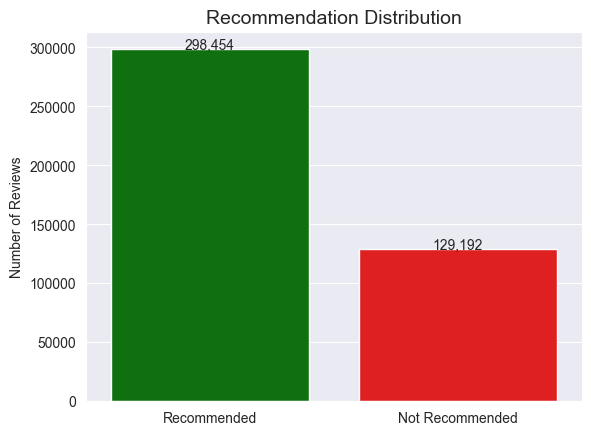

In [4]:
#plotting Recommendation Distribution
#count values
counts = df['recommendation'].value_counts().reindex(['Recommended', 'Not Recommended'])

#set style
sns.set_style("darkgrid")

#create bar plot
ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    palette=['g', 'r']
)

#add labels and title
ax.set_title("Recommendation Distribution", fontsize=14)
ax.set_xlabel("")
ax.set_ylabel("Number of Reviews")

#add value labels on top
for i, v in enumerate(counts.values):
    ax.text(
        i,
        v + 0.5,
        f'{int(v):,}',
        ha='center'
    )

#plot
plt.show()

In [5]:
#turning recommendation column into a sentiment integer
df['sentiment'] = df['recommendation'].apply(lambda x: 1 if x == 'Recommended' else 0)

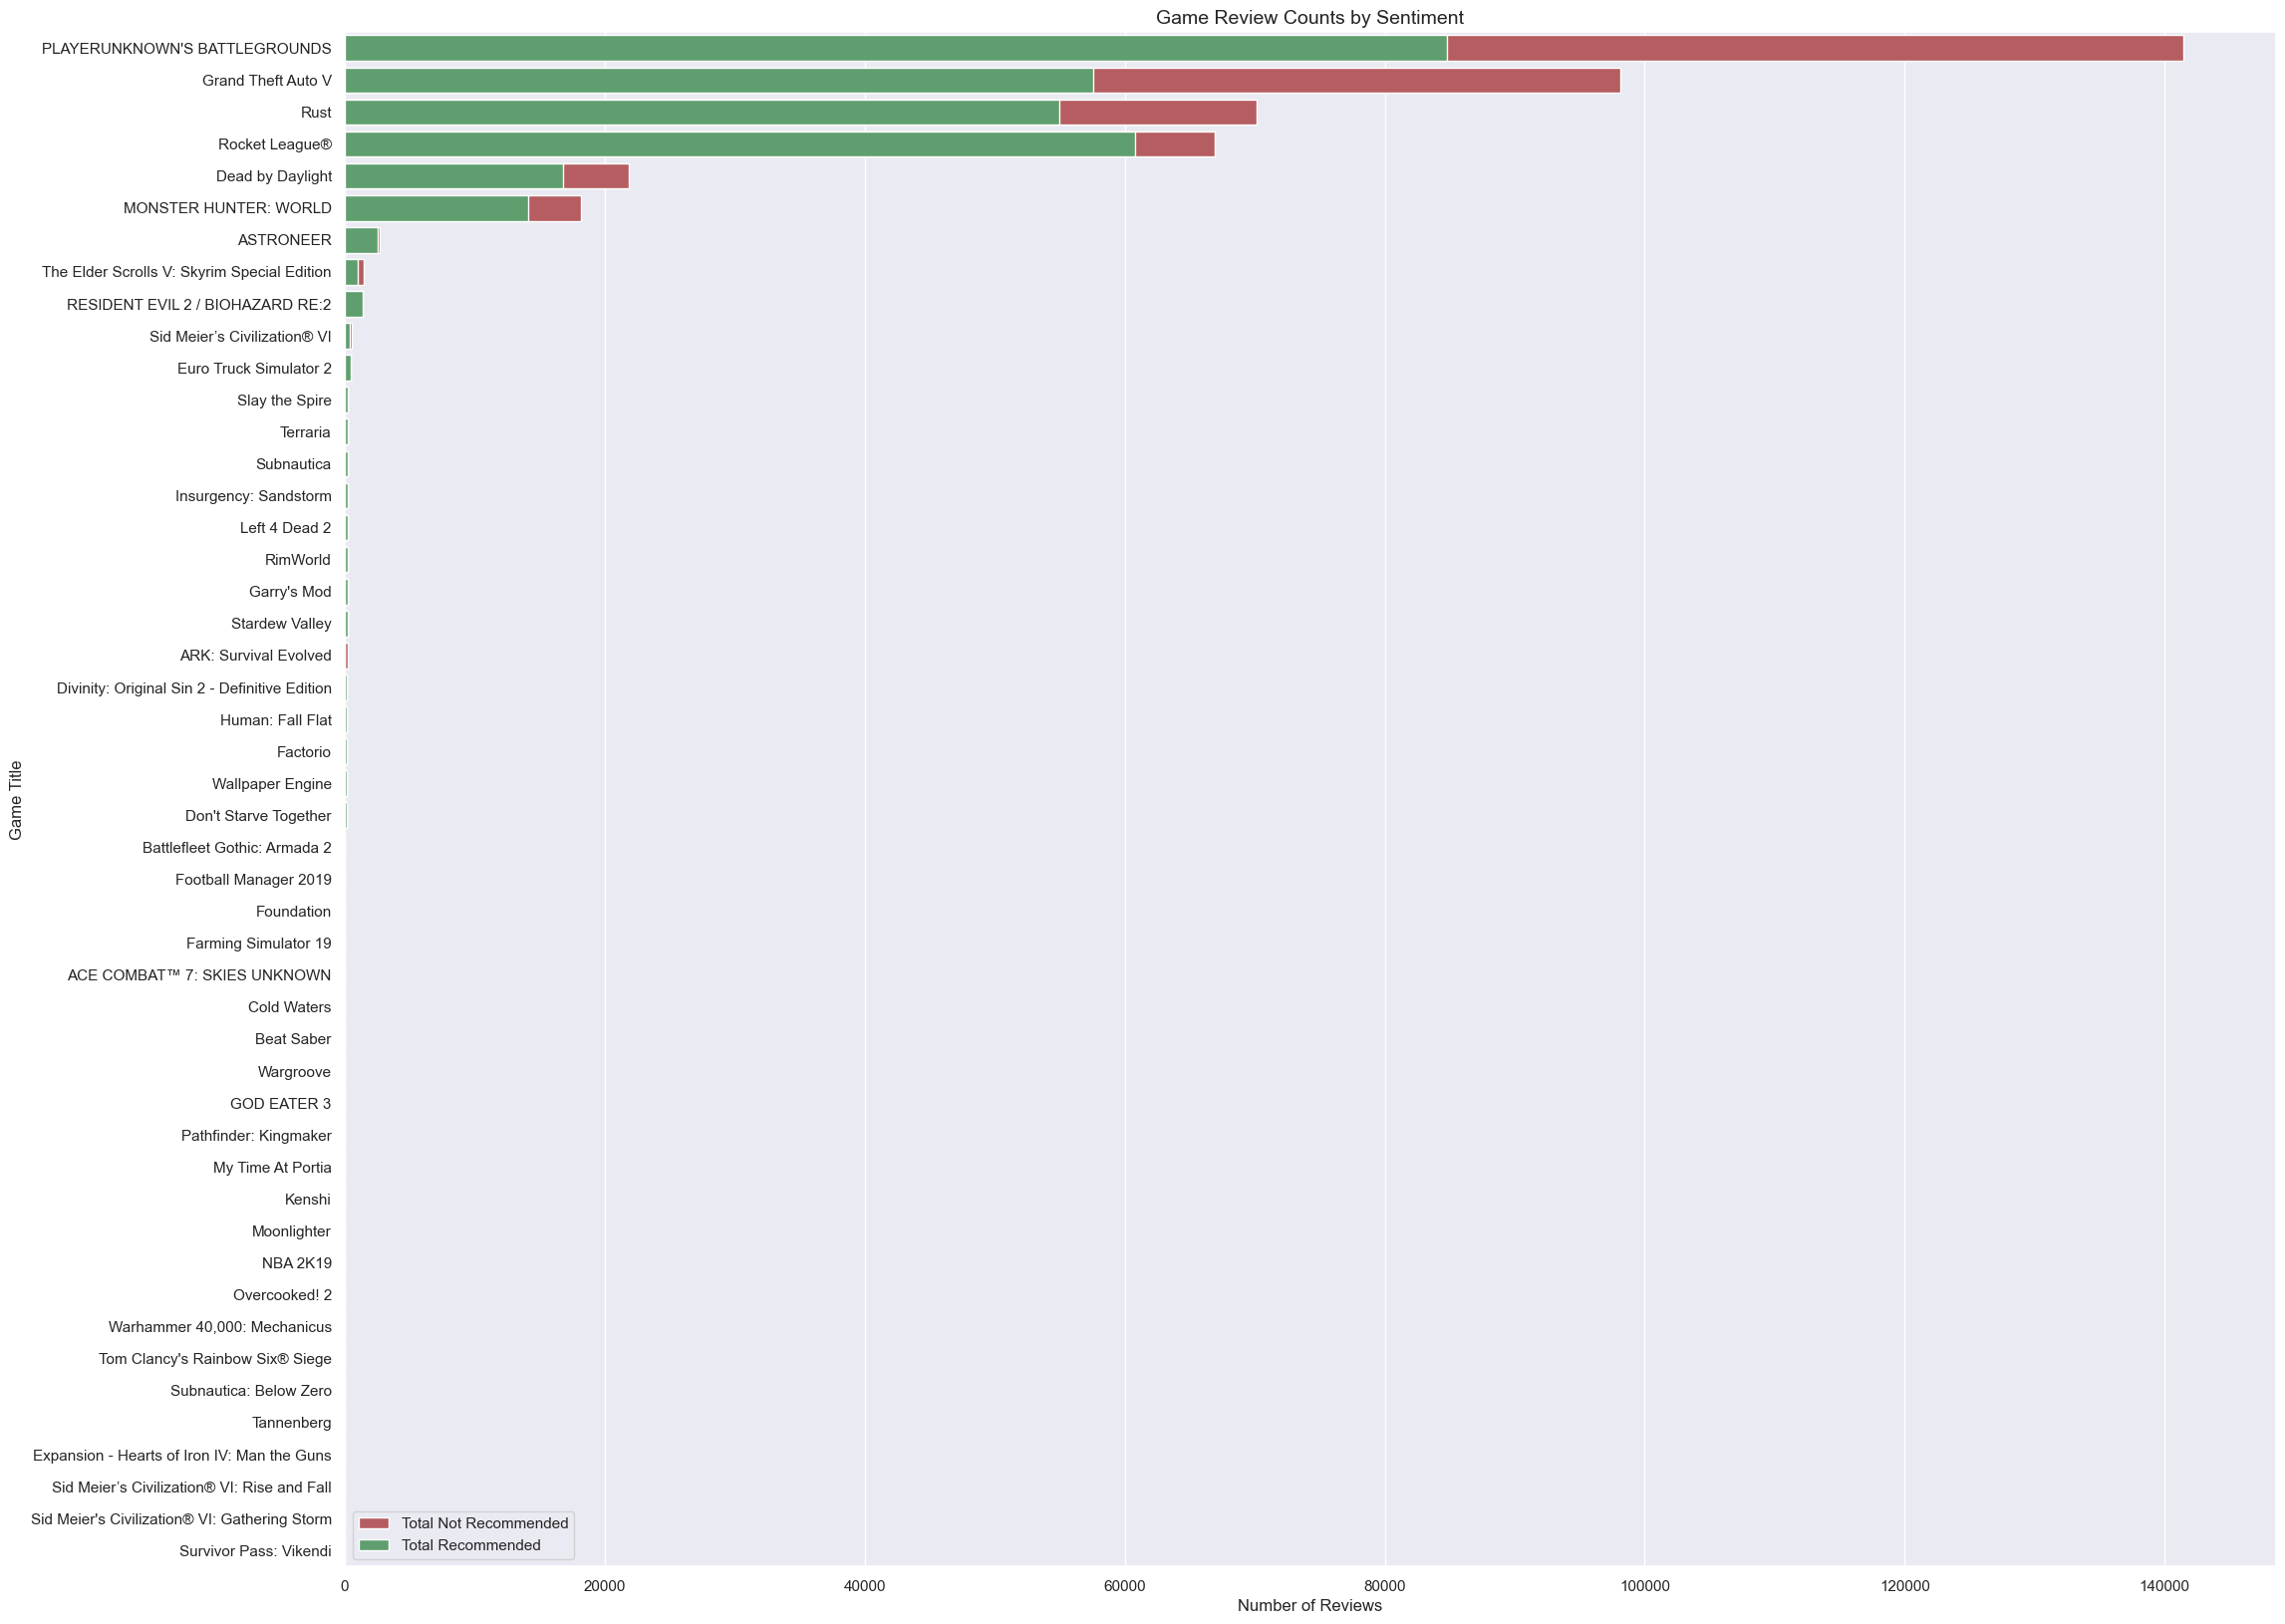

In [6]:
#plotting game review counts by sentiment

reviews_count = df.groupby(['title'])['review'].count().sort_values(ascending=False)
reviews_count = reviews_count.reset_index()
reviews_count_pos = df.groupby(['title', 'sentiment'])['review'].count().sort_values(ascending=False)
reviews_count_pos = reviews_count_pos.reset_index()
reviews_count_pos = reviews_count_pos[reviews_count_pos['sentiment'] == 1]


sns.set(style="darkgrid")
plt.figure(figsize=(25,20))

#first barplot (red)
ax = sns.barplot(
    y=reviews_count['title'],
    x=reviews_count['review'],
    data=reviews_count,
    label="Total Not Recommended",
    color="r"
)

#second barplot (green overlay)
sns.barplot(
    y=reviews_count_pos['title'],
    x=reviews_count_pos['review'],
    data=reviews_count_pos,
    label="Total Recommended",
    color="g",
    ax=ax
)

#set labels and title
ax.set_title("Game Review Counts by Sentiment", fontsize=14)
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Game Title")

#show legend
ax.legend()

#plot
plt.show()

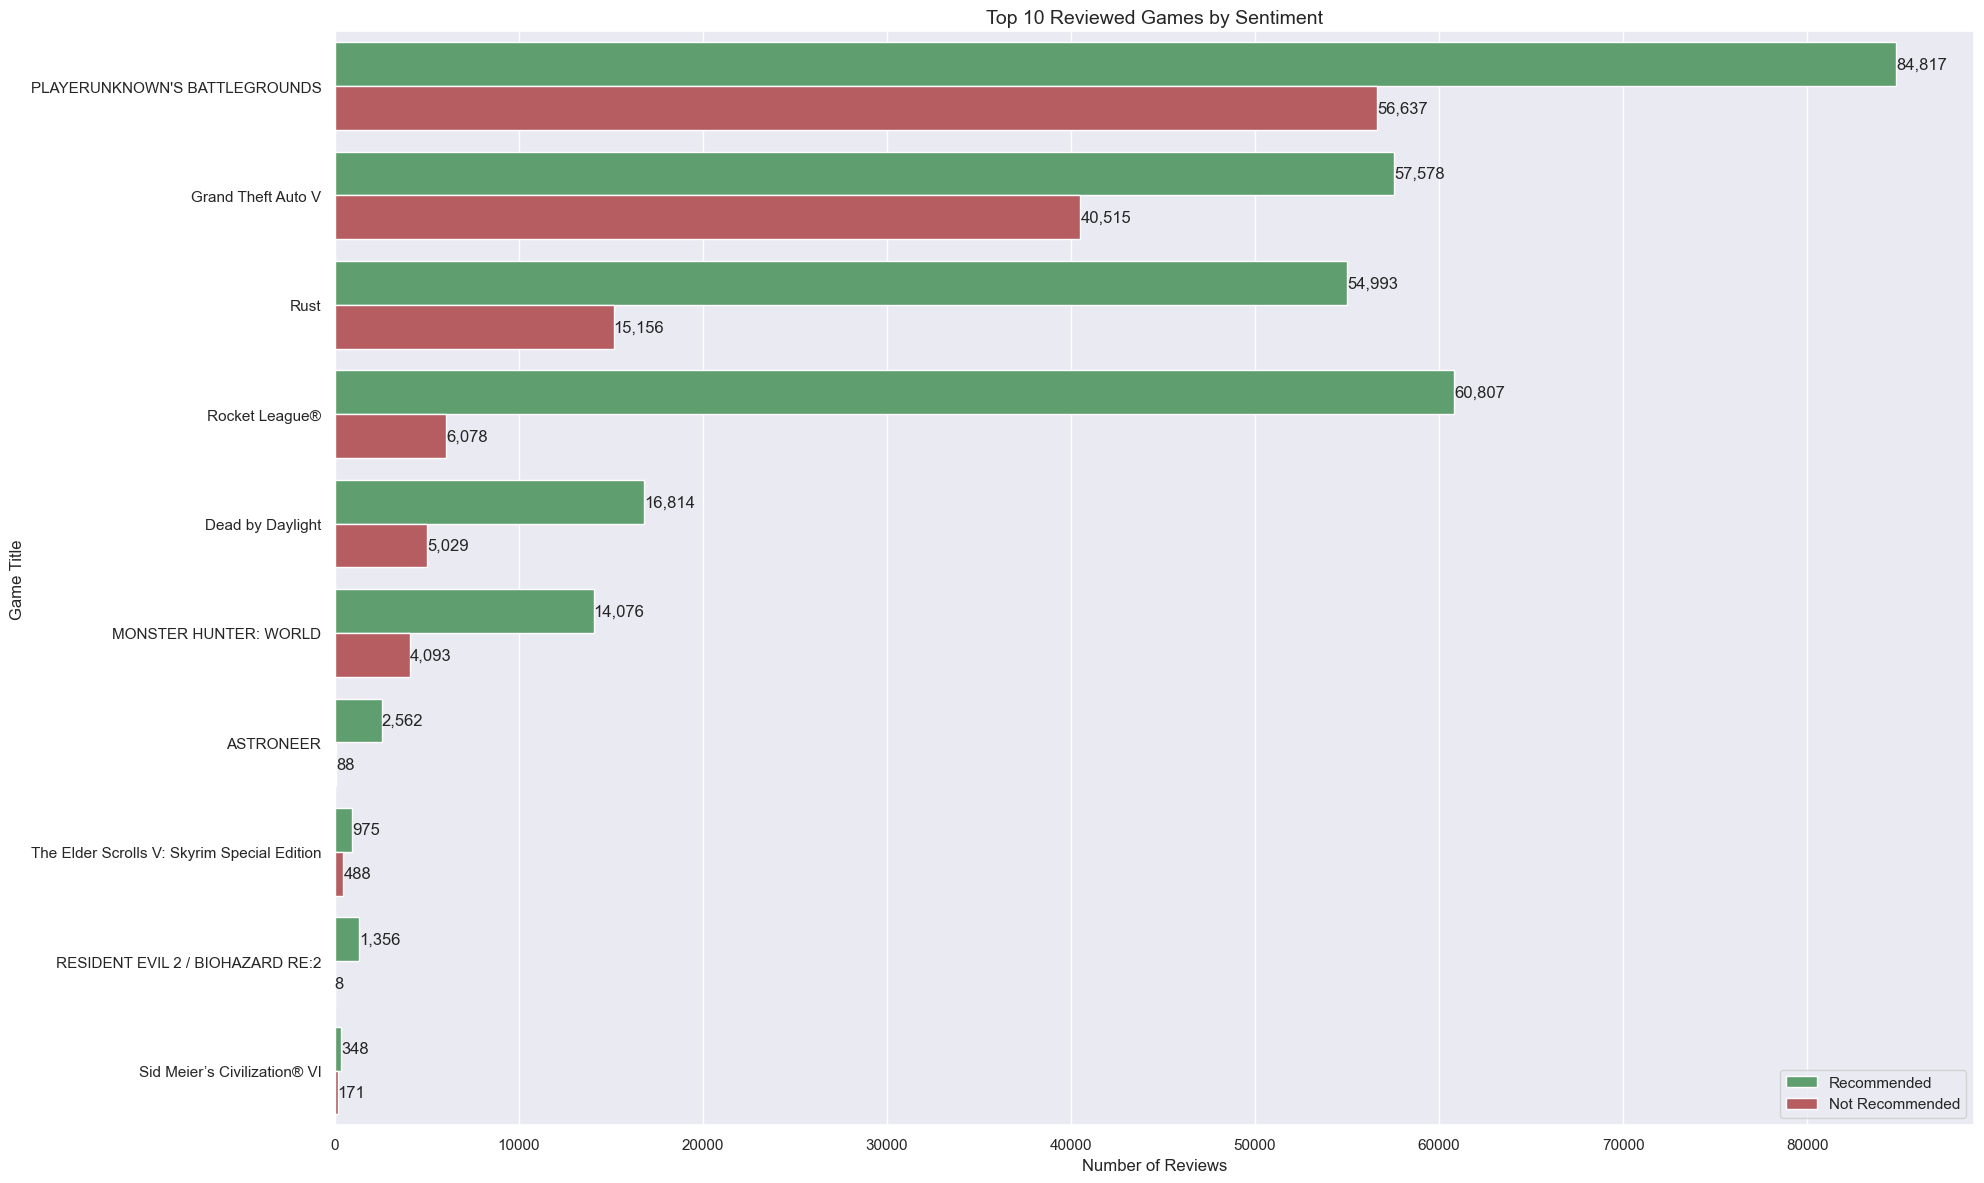

In [7]:
#aggregate counts
counts = df.groupby(['title', 'sentiment'])['review'].count().reset_index()

#map labels
counts['sentiment_label'] = counts['sentiment'].map({
    1: 'Recommended',
    0: 'Not Recommended'
})

#top 10 games by total reviews
top_titles = (
    counts.groupby('title')['review']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

counts_top = counts[counts['title'].isin(top_titles)].copy()

#order titles (descending total reviews)
counts_top['title'] = pd.Categorical(
    counts_top['title'],
    categories=top_titles,
    ordered=True
)

#within each title, sort so larger value comes first
counts_top = counts_top.sort_values(
    by=['title', 'review'],
    ascending=[True, False]
)

#plot
sns.set(style="darkgrid")
plt.figure(figsize=(20, 12))

ax = sns.barplot(
    data=counts_top,
    y='title',
    x='review',
    hue='sentiment_label',
    palette={'Recommended': 'g', 'Not Recommended': 'r'}
)

ax.set_title("Top 10 Reviewed Games by Sentiment", fontsize=14)
ax.set_xlabel("Number of Reviews")
ax.set_ylabel("Game Title")

# Add labels with commas
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.text(
            width + 1,
            p.get_y() + p.get_height()/2,
            f'{int(width):,}',
            va='center'
        )

ax.legend(title="")
plt.tight_layout()
plt.show()

In [8]:
df.head()

,date_posted,funny,helpful,hour_played,is_early_access_review,recommendation,review,title,clean_review,sentiment
0,2019-02-10,2,4,578,False,Recommended,&gt Played as German Reich&gt Declare war on B...,Expansion - Hearts of Iron IV: Man the Guns,gt played as german reichgt declare war on bel...,1
1,2019-02-10,0,0,184,False,Recommended,yes.,Expansion - Hearts of Iron IV: Man the Guns,yes,1
2,2019-02-07,0,0,892,False,Recommended,Very good game although a bit overpriced in my...,Expansion - Hearts of Iron IV: Man the Guns,very good game although a bit overpriced in my...,1
3,2018-06-14,126,1086,676,False,Recommended,Out of all the reviews I wrote This one is pro...,Dead by Daylight,out of all the reviews i wrote this one is pro...,1
4,2017-06-20,85,2139,612,False,Recommended,Disclaimer I survivor main. I play games for f...,Dead by Daylight,disclaimer i survivor main i play games for fu...,1


In [9]:
#tokenise review column
lemmatizer = WordNetLemmatizer()

def tokenise(reviews):
    stop_words = set(stopwords.words('english'))
    custom_stopwords = {'game', 'play', 'played'}  # add domain noise here
    stop_words.update(custom_stopwords)

    clean_reviews = []

    for review in reviews:
        if not isinstance(review, str):
            clean_reviews.append("")
            continue

        review = review.lower()
        review = re.sub(r"[^a-zA-Z\s]", "", review)
        tokens = re.findall(r'\b[a-zA-Z]{2,}\b', review)

        tokens = [
            lemmatizer.lemmatize(word)
            for word in tokens
            if word not in stop_words
        ]

        clean_reviews.append(" ".join(tokens))

    return clean_reviews

# preprocessing
df['clean_review'] = tokenise(df['review'])

# remove missing values
df['clean_review'] = df['clean_review'].fillna("").astype(str)

# remove low-quality / very short reviews 
df = df[df['clean_review'].str.split().str.len() > 3]

# Show a few cleaned reviews
for i, rev in enumerate(df['clean_review'][:5], 1):
    print(f"\nCleaned Review {i}: {rev}")


Cleaned Review 1: gt german reichgt declare war belgiumgt cant break belgium go francegt capitulate france order get belgiumgt get true blitzkrieg achievementthis dad

Cleaned Review 2: good although bit overpriced opinion id prefer playing mod historical accuracy although vanilla version good aswell

Cleaned Review 3: review wrote one probably serious one wrote starter community suck like every online dont wanna talk theyre jerk wanna say suck camped blah blah blah rare get nice compliment people gamebut dont talk community either unlike online game one doesnt mic system dont worry hearing twelve year old cry baby raging nothing time talk people beginning match start survivor end match killer survivor end chat one killer talk everyone match though mostly say gg good gameas survivor basically every man sneaky say screw player try good team mate rescue get hook someone jerk chat match know save get hooked mostly killer find fun playing survivor someone gotta killer hear people enjoy pl

In [10]:
#split reviews by sentiment
pos_reviews = df[df['sentiment'] == 1]['clean_review']
neg_reviews = df[df['sentiment'] == 0]['clean_review']

#tokenise separately
pos_tokens = tokenise(pos_reviews)
neg_tokens = tokenise(neg_reviews)

#flatten into word lists
pos_words = " ".join(pos_tokens).split()
neg_words = " ".join(neg_tokens).split()

#count frequencies
pos_counts = Counter(pos_words)
neg_counts = Counter(neg_words)

#top 20 words
print("Top Positive Words:", pos_counts.most_common(20))
print("Top Negative Words:", neg_counts.most_common(20))

Top Positive Words: [('fun', 61509), ('get', 54036), ('good', 48862), ('like', 46714), ('great', 37951), ('time', 37666), ('friend', 35052), ('one', 33420), ('really', 30528), ('still', 26669), ('dont', 26600), ('would', 26412), ('people', 25946), ('player', 25647), ('best', 25422), ('playing', 24435), ('make', 23571), ('hour', 23131), ('even', 22482), ('lot', 21328)]
Top Negative Words: [('get', 36750), ('dont', 28480), ('like', 27987), ('time', 27077), ('player', 25446), ('even', 23368), ('money', 22393), ('fun', 19975), ('buy', 19705), ('server', 19045), ('people', 19008), ('good', 17667), ('one', 17039), ('take', 16809), ('make', 16722), ('still', 15767), ('online', 15589), ('cant', 15560), ('really', 14677), ('would', 14208)]


In [11]:

#tokenising into 2-word phrases
def get_top_ngrams(tokens_list, n=2, top_k=20):
    all_tokens = " ".join(tokens_list).split()
    n_grams = list(ngrams(all_tokens, n))
    return Counter(n_grams).most_common(top_k)

print("Top Positive Bigrams:", get_top_ngrams(pos_tokens, 2))
print("Top Negative Bigrams:", get_top_ngrams(neg_tokens, 2))

Top Positive Bigrams: [(('received', 'free'), 12116), (('product', 'received'), 12101), (('gt', 'gt'), 8391), (('early', 'access'), 5849), (('one', 'best'), 5420), (('fun', 'friend'), 4861), (('rocket', 'league'), 4835), (('monster', 'hunter'), 3941), (('really', 'fun'), 3865), (('single', 'player'), 3812), (('best', 'ever'), 3397), (('feel', 'like'), 3391), (('battle', 'royale'), 3287), (('lot', 'fun'), 3198), (('would', 'recommend'), 3173), (('really', 'good'), 3070), (('much', 'fun'), 2771), (('gta', 'online'), 2723), (('nc', 'nc'), 2667), (('pretty', 'good'), 2580)]
Top Negative Bigrams: [(('take', 'two'), 7384), (('single', 'player'), 5769), (('dont', 'buy'), 4612), (('early', 'access'), 4193), (('regionlockchina', 'regionlockchina'), 3178), (('gta', 'online'), 3148), (('received', 'free'), 3146), (('product', 'received'), 3135), (('shark', 'card'), 3002), (('region', 'lock'), 2476), (('feel', 'like'), 2428), (('lag', 'lag'), 2399), (('cant', 'even'), 2279), (('loading', 'screen')

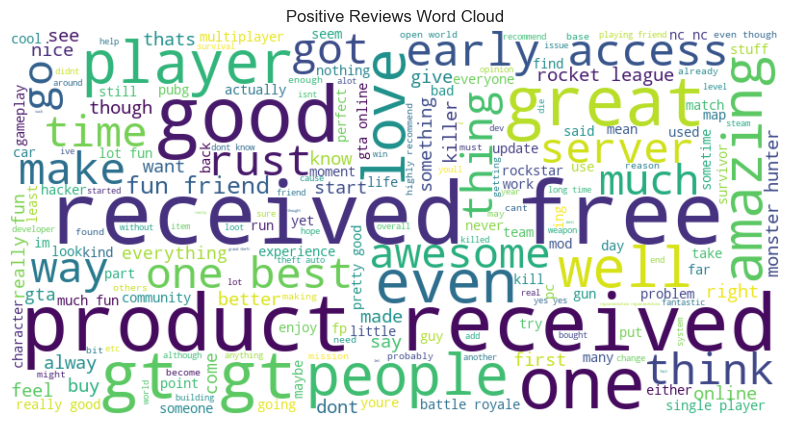

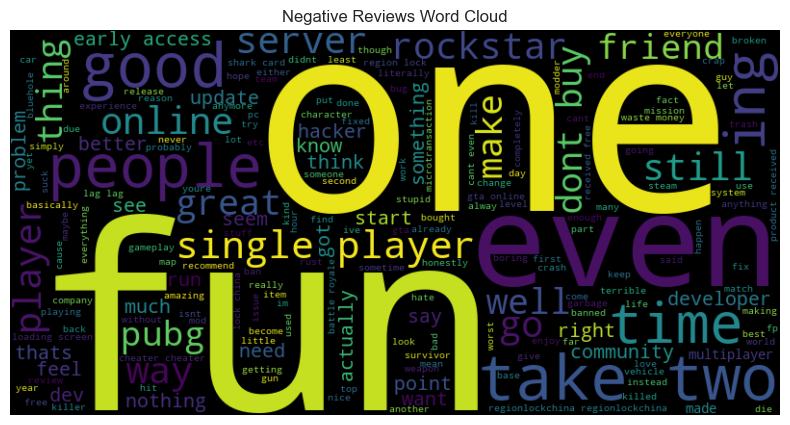

In [12]:
#positive word cloud
pos_text = " ".join(pos_words)
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(pos_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

#negative word cloud
neg_text = " ".join(neg_words)
wordcloud_neg = WordCloud(width=800, height=400, background_color='black').generate(neg_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

In [13]:
#TF-IDF analysis
vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')
X = vectorizer.fit_transform(df['clean_review'])

feature_names = vectorizer.get_feature_names_out()

# Get top TF-IDF words overall
import numpy as np
scores = np.asarray(X.mean(axis=0)).ravel()
top_words = [(feature_names[i], scores[i]) for i in scores.argsort()[-20:]]

print(sorted(top_words, key=lambda x: -x[1]))

[('fun', np.float64(0.04021157872247794)), ('good', np.float64(0.0354002890834835)), ('like', np.float64(0.029552991021857305)), ('great', np.float64(0.02786910449600715)), ('time', np.float64(0.02493016930859583)), ('friend', np.float64(0.024379302435204364)), ('dont', np.float64(0.02347229494531432)), ('best', np.float64(0.02302634439321027)), ('free', np.float64(0.02222040819788431)), ('really', np.float64(0.021173199873000946)), ('game', np.float64(0.02056241685060307)), ('product', np.float64(0.02020762876541392)), ('received', np.float64(0.019905736576228485)), ('buy', np.float64(0.019708223665062165)), ('player', np.float64(0.01845593977109672)), ('server', np.float64(0.018075947494060583)), ('playing', np.float64(0.017682552792476727)), ('people', np.float64(0.017614612512251035)), ('love', np.float64(0.017602647856881332)), ('hour', np.float64(0.017059320300685413))]


In [14]:
#positive vs negative words
pos_set = set(pos_words)
neg_set = set(neg_words)

print("Positive-only words:", list(pos_set - neg_set)[:20])
print("Negative-only words:", list(neg_set - pos_set)[:20])

Positive-only words: ['rotundamente', 'mmi', 'valhallai', 'holyshitfinallyitsherepngjpggifexegt', 'engineballisticsgunplaygameplayvisuals', 'adventuregameplay', 'knowprice', 'smsgg', 'sinkeramazingnow', 'acomplsih', 'shapemyers', 'whaaaaaaaat', 'gamenaked', 'helpfulmore', 'bolja', 'tacticsteamwork', 'unbarableupdate', 'dorner', 'originallegacyrust', 'bedwake']
Negative-only words: ['belowtake', 'neededoops', 'fuuuuuuuuuck', 'niedopracowanie', 'jtszottam', 'dissopointing', 'advancedfun', 'awesomehowevera', 'weakunfair', 'modswait', 'generalfinal', 'makingtl', 'lobbydead', 'veryclunky', 'memelords', 'ulow', 'identifity', 'bugslast', 'bucketpubgs', 'everydoby']


/var/folders/3d/sq_wrq717xq82hc4jm2ryyc40000gn/T/ipykernel_54918/1430055565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='hour_played', palette={'1': 'g', '0': 'r'})


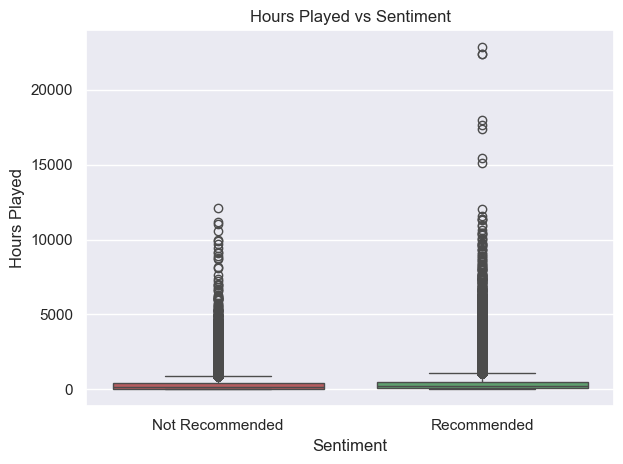

In [23]:
#sentiment vs hours played
sns.set(style="darkgrid")
sns.boxplot(data=df, x='sentiment', y='hour_played', palette={'1': 'g', '0': 'r'})
plt.xticks([0,1], ['Not Recommended', 'Recommended'])
plt.title("Hours Played vs Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Hours Played")

plt.tight_layout()
plt.show()

/var/folders/3d/sq_wrq717xq82hc4jm2ryyc40000gn/T/ipykernel_54918/1192848282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment', y='helpful', palette={'1': 'g', '0': 'r'})


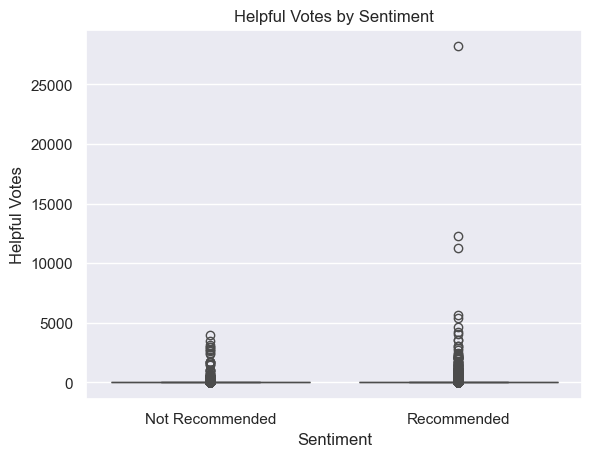

In [24]:
#helpful votes vs sentiment
sns.set(style="darkgrid")
sns.boxplot(data=df, x='sentiment', y='helpful', palette={'1': 'g', '0': 'r'})
plt.xticks([0,1], ['Not Recommended', 'Recommended'])
plt.title("Helpful Votes by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Helpful Votes")

plt.show()

In [17]:
# Positive vs Negative TF-IDF
pos_df = df[df['recommendation'] == 'Recommended']
neg_df = df[df['recommendation'] == 'Not Recommended']

vectorizer = TfidfVectorizer(max_features=500, stop_words='english')

X_pos = vectorizer.fit_transform(pos_df['clean_review'])
X_neg = vectorizer.fit_transform(neg_df['clean_review'])

def get_top_words(X, feature_names):
    scores = np.asarray(X.mean(axis=0)).ravel()
    return sorted(
        [(feature_names[i], scores[i]) for i in scores.argsort()[-15:]],
        key=lambda x: -x[1]
    )

print("\nTop Positive Words:")
print(get_top_words(X_pos, vectorizer.get_feature_names_out()))

print("\nTop Negative Words:")
print(get_top_words(X_neg, vectorizer.get_feature_names_out()))


Top Positive Words:
[('future', np.float64(0.05379512191382253)), ('gonna', np.float64(0.04683322158732846)), ('graphic', np.float64(0.03844929273820523)), ('long', np.float64(0.03523853087710608)), ('better', np.float64(0.03346752050051984)), ('friend', np.float64(0.033216377790144774)), ('transaction', np.float64(0.02821572191783693)), ('free', np.float64(0.02816770104306577)), ('released', np.float64(0.026670612287021337)), ('purchase', np.float64(0.0260879536191502)), ('right', np.float64(0.025898330277772354)), ('gaming', np.float64(0.025188304148714716)), ('man', np.float64(0.024872034781725876)), ('positive', np.float64(0.021718772402780785)), ('dlc', np.float64(0.0214108393063366))]

Top Negative Words:
[('dont', np.float64(0.036584240172880506)), ('like', np.float64(0.031961789408868596)), ('money', np.float64(0.03001852515637954)), ('server', np.float64(0.029855916256569096)), ('time', np.float64(0.029702009967414338)), ('buy', np.float64(0.028705019128241378)), ('player', n